In [1]:
# Imports
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [2]:
# Read excel file
df = pd.read_excel('integrated_data_with_sic.xlsx')
print(df.shape)

(16753, 37)


In [3]:
# Preprocessing Part
# Combine year + Quarter
df['quarter'] = df['quarter'].str.extract('(\d+)').astype(int)
df['year_quarter'] = df['year']*10 + df['quarter']

# Add productive population (15 ~ 24, 15 ~ 64) 경제 활동인구 
a15_64 = [24900.33333, 25418.66667, 25224.33333, 25249.33333, 25288, 25803.66667, 25731, 25494.66667, 25346.33333,
          25790.66667, 25632, 25552.66667, 25398.66667, 25702.33333, 25429.66667, 25359.66667]
a15_24 = [1480, 1582.666667, 1546, 1466.666667, 1560.666667, 1607.333333, 1564, 1439.333333, 1475.666667, 1470.666667, 1456.333333,
          1389.666667, 1387, 1405.666667, 1341.333333, 1259.666667]
a15_64 = list(map(int, a15_64))
a15_24 = list(map(int, a15_24))

df['a15_64'] = df.apply(lambda row: a15_64[int((row['year']-2021) * 4 + row['quarter'] - 1)], axis=1)
df['a15_24'] = df.apply(lambda row: a15_24[int((row['year']-2021) * 4 + row['quarter'] - 1)], axis=1)

# Add Covid-19 data

url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
covid_data = pd.read_csv(url)
covid_data["date"] = pd.to_datetime(covid_data["date"])

korea = covid_data[covid_data["location"] == "South Korea"].copy()
korea = korea[(korea["date"] >= "2021-01-01") & (korea["date"] <= "2024-12-31")]
korea_indexed = korea.set_index('date')
korea_quarterly = korea_indexed.resample('QE').mean(numeric_only=True)
#  'reproduction_rate' 도 고려해볼만 함 (감영 재생산 지수)
korea_quarterly = korea_quarterly['new_cases_per_million'].astype(int).to_numpy()
korea_quarterly = np.append(korea_quarterly, 0)
print(korea_quarterly)

df['covid'] = df.apply(lambda row: korea_quarterly[int((row['year']-2021) * 4 + row['quarter'] - 1)], axis=1)

[   9   11   31   64 2444 1342 1320  847  452  265  535    0    0    0
    0    0]


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
# Classifying Variable Types
num_features = df.select_dtypes(include='number').columns
str_features = df.select_dtypes(exclude='number').columns

In [6]:
# Handling Missing Values 

In [7]:
# # 그래프 개형 확인 
# fig, ax = plt.subplots(figsize=(10, 8))
# ax.scatter(df['year_quarter'], df['heat_wave_days']) 

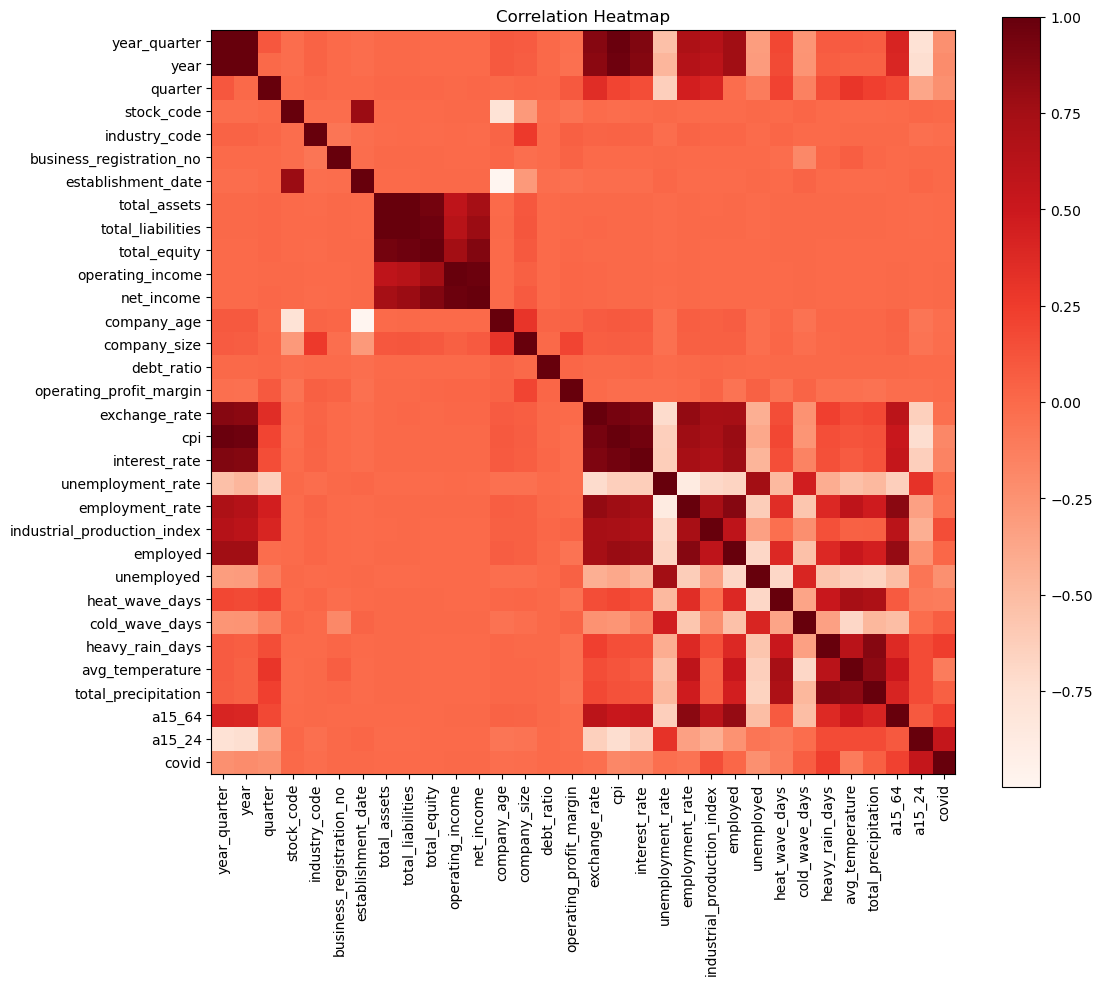

In [8]:


corr = df[num_features].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr[num_features], cmap='Reds')

plt.colorbar()
plt.xticks(range(len(num_features)), num_features, rotation=90)
plt.yticks(range(len(num_features)), num_features)

plt.title("Correlation Heatmap")
plt.show()

In [9]:
# threshold 설정
threshold = 0.8

# 상관행렬 절댓값
corr_matrix = corr.abs()

# 상삼각 행렬만 사용 (중복 제거)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# threshold 이상인 feature 쌍 찾기
high_corr_pairs = [
    (column, row, upper.loc[row, column])
    for column in upper.columns
    for row in upper.index
    if pd.notnull(upper.loc[row, column]) and upper.loc[row, column] > threshold
]

# 결과 출력
for f1, f2, value in high_corr_pairs:
    print(f"{f1}  <->  {f2} : {value:.3f}")

year  <->  year_quarter : 0.995
total_liabilities  <->  total_assets : 0.995
total_equity  <->  total_assets : 0.941
total_equity  <->  total_liabilities : 0.967
net_income  <->  total_equity : 0.886
net_income  <->  operating_income : 0.971
company_age  <->  establishment_date : 0.997
exchange_rate  <->  year_quarter : 0.875
exchange_rate  <->  year : 0.845
cpi  <->  year_quarter : 0.980
cpi  <->  year : 0.965
cpi  <->  exchange_rate : 0.933
interest_rate  <->  year_quarter : 0.893
interest_rate  <->  year : 0.882
interest_rate  <->  exchange_rate : 0.902
interest_rate  <->  cpi : 0.946
employment_rate  <->  exchange_rate : 0.814
employment_rate  <->  unemployment_rate : 0.875
employed  <->  employment_rate : 0.873
total_precipitation  <->  heavy_rain_days : 0.873
total_precipitation  <->  avg_temperature : 0.842
a15_64  <->  employment_rate : 0.857
a15_64  <->  employed : 0.806
